# NMnist Dataset
This Dataset is used for first proof-of-concept test. <br>
Here we can try out different represenations and preprocessing on events

In [1]:
import tonic
import torch
import numpy as np
from torchvision.transforms import transforms
import matplotlib.pyplot as plt

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = tonic.datasets.NMNIST(save_to="../data/NMNIST", train=False)

Shape of frames: (2, 3, 34, 34)
Target: [1 1]


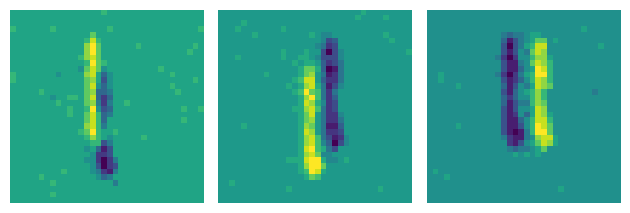

In [3]:
# frame representation
sensor_size = tonic.datasets.NMNIST.sensor_size
frame_transform = transforms.Compose([
    tonic.transforms.ToFrame(sensor_size=sensor_size, n_time_bins=3),
    lambda x: np.diff(x, axis=1).squeeze(axis=1) # do the difference operation here instead of later
])
events, target = dataset[1000]
x,y = dataset[999]
target = np.array([target, y])
frames = np.array([frame_transform(events), frame_transform(x)])
print("Shape of frames:", frames.shape)
print("Target:", target)

fig, axes = plt.subplots(1, len(frames[0]))
for axis, frame in zip(axes, frames[0]):
    # axis.imshow(frame[1] - frame[0])
    axis.imshow(frame)
    axis.axis("off")
plt.tight_layout()
plt.show()

Try to put that into dense net<br>
Because it is only a linear input layer, just take the first image and flatten it before input

In [4]:
frames.shape
batch = torch.tensor(frames[:,0,:,:], dtype=torch.float32)
batch_flat = batch.view(batch.size(0), -1)
print(batch_flat.shape)

torch.Size([2, 1156])


Put this into transform

In [5]:
flat_transform = transforms.Compose([
    tonic.transforms.ToFrame(sensor_size=sensor_size, n_time_bins=3),
    lambda x: np.diff(x, axis=1).squeeze(axis=1),  # do the difference operation here instead of later
    # lambda x: np.array(x[0].reshape(-1), dtype=np.float32) # flatten the frame
    lambda x: np.array(x[0])
])
dataset = tonic.datasets.NMNIST(save_to="../data/NMNIST", train=False, transform=flat_transform)
print(dataset[100][0].shape)
print(dataset[100][0].dtype)

(34, 34)
int16


## Important!!
The dense net wants inputs of [batchsize, channels=1, width, height] <br>
because preprocessing is done by forward pass

Shape of samples: torch.Size([32, 34, 34])
tensor(7, dtype=torch.int16) tensor(-8, dtype=torch.int16)


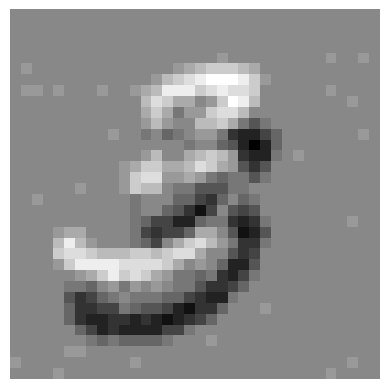

In [6]:
# try do put it into dataLoader
train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
samples, labels = next(iter(train_loader))
print("Shape of samples:", samples.shape)
print(samples[0].max(), samples[0].min())
plt.imshow(samples[0].reshape(34, 34), cmap='gray')
plt.axis('off')
plt.show()

Look if the model will take it

In [7]:
model = torch.nn.Sequential(
    torch.nn.Linear(1156, 64),
    torch.nn.BatchNorm1d(64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 128),
    torch.nn.BatchNorm1d(128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.BatchNorm1d(64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 10),
)

## Voxel Grid

## Test own version

In [8]:
import sys
sys.path.append("../")
sys.path.append("../src/")
sys.path.append("../src/utils/")
import event_represenations

In [9]:
dataset = tonic.datasets.NMNIST(save_to="../data/NMNIST", train=False)
print(f"Shape: {dataset[0][0].shape}, dtype: {dataset[0][0].dtype}, max P: {dataset[0][0]['p'].max()}, min P: {dataset[0][0]['p'].min()}")
num_bins = 10
image = dataset[100][0]
vg = event_represenations.events_to_voxel(image["x"], image["y"], image["t"], image["p"], num_bins, sensor_size=tonic.datasets.NMNIST.sensor_size)
print("Shape of voxel grid:", vg.shape)
print("Voxel grid max:", vg.max(), "min:", vg.min())

Shape: (5293,), dtype: [('x', '<i8'), ('y', '<i8'), ('t', '<i8'), ('p', '<i8')], max P: 1, min P: 0
Shape of voxel grid: (10, 34, 34)
Voxel grid max: 8.0 min: 0.0


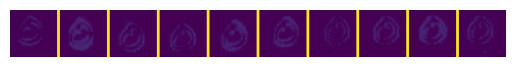

In [10]:
plt.imshow(event_represenations.get_voxel_grid_as_image(vg))
plt.axis('off')
plt.show()

Test as transform

In [ ]:
trans = transforms.Compose([
    lambda ev: event_represenations.events_to_voxel(ev["x"], ev["y"], ev["t"], ev["p"], num_bins=20, sensor_size=tonic.datasets.NMNIST.sensor_size),  # create voxel grid from events
    lambda x: x.reshape(4, 5, 34, 34)
])
dataset = tonic.datasets.NMNIST(save_to="../data/NMNIST", train=False, transform=trans)
print(dataset[100][0].shape)

(20, 34, 34)
